# 1.6 Resource availabilities

**Responsible:** _(Aldo Patrone)_

Fits the availability model used by "resources/availability.py" from the BPIC-17 log and exports the parameters as an artifact the engine loads at runtime.

- **Basic:** interval / shift calendar (Mon–Fri 08:00–18:00) applied to every resource.
- **Advanced:** per-resource availability calendars learned from observed activity timestamps (when is each resource actually working). There is no system-vs-human attribute in BPIC-17, so a data-driven per-resource calendar is used instead of a fixed system-always-on rule.

Mode selection is artifact-driven: if "results/availability_calendars.json" exists the engine uses the advanced model automatically, otherwise the basic interval.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from resources.log_loader import load_slim_log
from resources import availability

df = load_slim_log('../data/BPI Challenge 2017.xes', '../data/bpic17_slim.parquet')
ts = pd.to_datetime(df['time:timestamp'], utc=True)
df = df.assign(weekday=ts.dt.weekday, hour=ts.dt.hour)
print(len(df), 'events,', df['org:resource'].nunique(), 'resources')

Matplotlib is building the font cache; this may take a moment.
/Users/aldo/Documents/Uni/Business Process Prediction, Simulation, and Optimization (IN0012)/2. Teil Gruppenabgabe/PracticalCourse/.venv/lib/python3.13/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/aldo/Documents/Uni/Business Process Prediction, Simulation, and Optimization (IN0012)/2. Teil Gruppenabgabe/PracticalCourse/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 31509/31509 [00:23<00:00, 1341.91it/s]


1202267 events, 149 resources


## Temporal activity pattern
The aggregate (weekday × hour) heatmap motivates the model: activity concentrates on weekday daytime, but a fixed Mon–Fri 08–18 window is only a rough approximation.

saved ../results/availability_heatmap.png


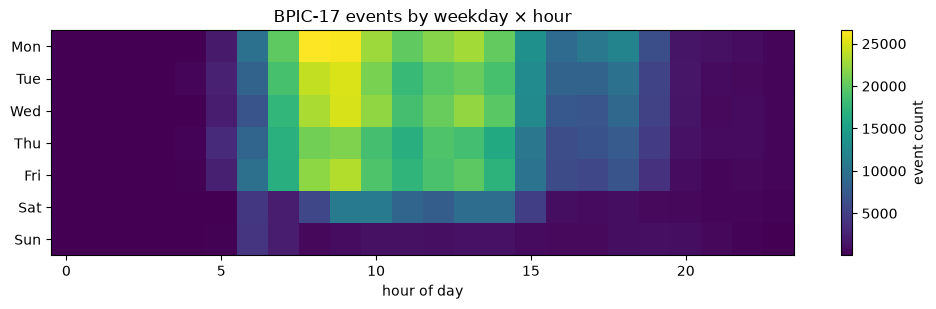

In [2]:
heat = df.groupby(['weekday', 'hour']).size().unstack(fill_value=0).reindex(index=range(7), columns=range(24), fill_value=0)
fig, ax = plt.subplots(figsize=(10, 3.2))
im = ax.imshow(heat.values, aspect='auto', cmap='viridis')
ax.set_yticks(range(7)); ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_xlabel('hour of day'); ax.set_title('BPIC-17 events by weekday × hour')
fig.colorbar(im, ax=ax, label='event count')
fig.tight_layout(); fig.savefig('../results/availability_heatmap.png', dpi=120)
print('saved ../results/availability_heatmap.png')

## Advanced: learned per-resource calendars
For each resource the model keeps the (weekday, hour) buckets whose event count reaches "max(min_events, threshold_frac × peak)", suppressing rare off-hours noise.

learned calendars for 149 resources; mean 44.4 active buckets of 168
saved ../results/availability_calendar_sizes.png


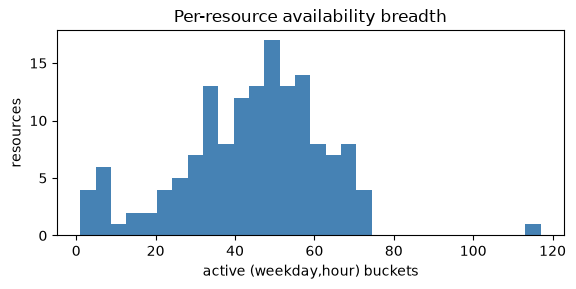

In [3]:
calendars = availability.learn_calendars(df)
availability.save_calendars(calendars, '../results/availability_calendars.json')
cal_t = {r: {(int(w), int(h)) for w, h in b} for r, b in calendars.items()}
sizes = [len(v) for v in cal_t.values()]
print('learned calendars for', len(cal_t), 'resources; mean %.1f active buckets of 168' % np.mean(sizes))

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(sizes, bins=30, color='steelblue')
ax.set_xlabel('active (weekday,hour) buckets'); ax.set_ylabel('resources')
ax.set_title('Per-resource availability breadth')
fig.tight_layout(); fig.savefig('../results/availability_calendar_sizes.png', dpi=120)
print('saved ../results/availability_calendar_sizes.png')

## Basic vs. advanced: event coverage
Share of real events that fall inside each availability model. The learned calendars capture far more of the real activity than the fixed interval, justifying the advanced model.

In [4]:
in_basic = ((df['weekday'] < 5) & (df['hour'] >= 8) & (df['hour'] < 18)).mean()
samp = df.sample(min(100000, len(df)), random_state=1)
in_cal = np.mean([(int(w), int(h)) in cal_t.get(str(r), set())
                  for r, w, h in zip(samp['org:resource'], samp['weekday'], samp['hour'])])
print('event coverage  | basic interval: %.1f%%  | learned calendars: %.1f%%' % (100*in_basic, 100*in_cal))

event coverage  | basic interval: 72.0%  | learned calendars: 96.4%


**Result:** The basic Mon–Fri 08–18 interval covers ~72% of real events. The learned per-resource calendars cover ~96%. The advanced model therefore reflects real resource availability much more faithfully while still constraining each resource to its own working pattern.